
===== Street action counts =====
action   CALL  FOLD  RAISE
street                    
flop      102    10      3
preflop    92    99     28
river      58    17      3
turn       73    14     11

===== Raise sizing (raise/pot) summary =====
         count      mean       std       min       25%       50%       75%  \
street                                                                       
flop       3.0  0.910885  0.573924  0.421053  0.595142  0.769231  1.155802   
preflop   28.0  1.661794  0.647606  0.560606  1.295455  1.550000  1.850000   
river      3.0  3.422498  2.490630  0.709288  2.331247  3.953206  4.779103   
turn      11.0  0.686736  0.849451  0.067792  0.294372  0.475248  0.634840   

              max  
street             
flop     1.542373  
preflop  3.000000  
river    5.605000  
turn     3.157895  

===== gpt-4.1-mini metrics (behavioral) =====
hands_seen_preflop: 219.000
VPIP_%: 51.142
PFR_%: 12.785
flop_agg_factor: 0.029
turn_agg_factor: 0.151
river_agg_factor: 0

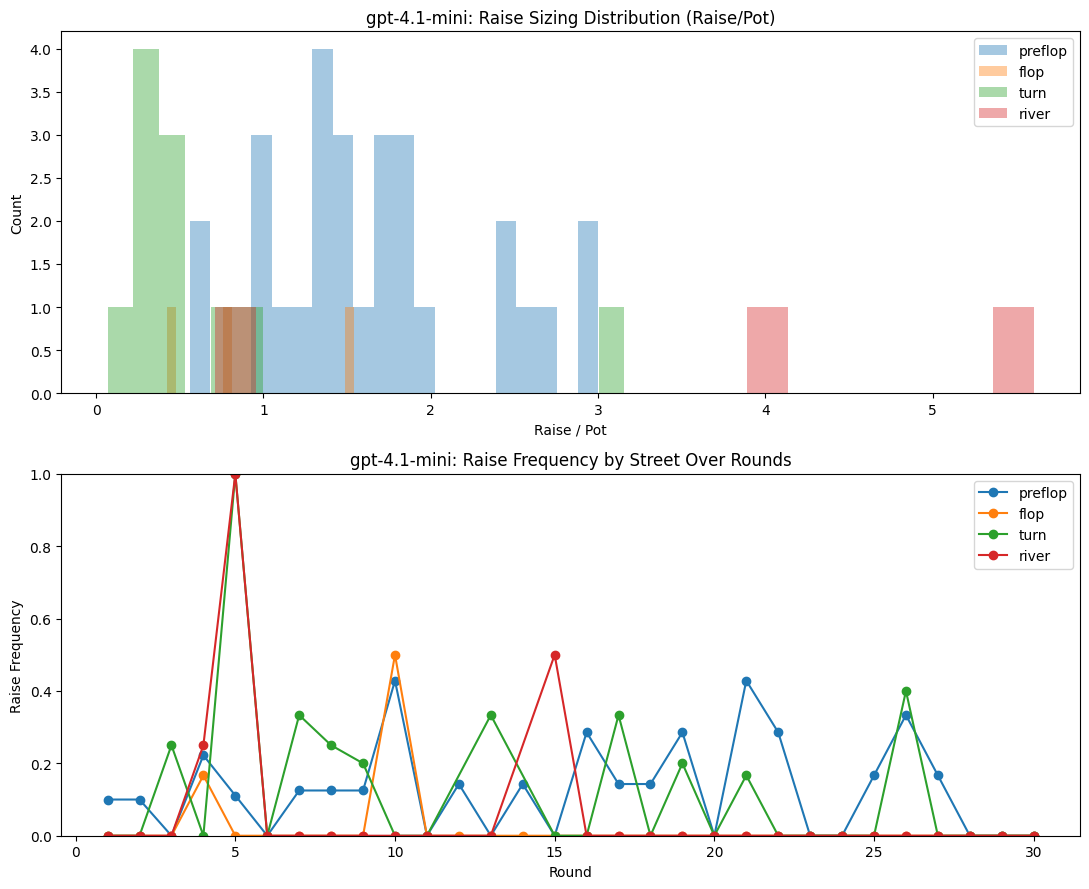


Saved one combined figure to: gpt-4.1-mini_behavior_summary.pdf


In [1]:
import json
import math
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = "results.json"
TARGET = "Alex Chen"  # The raw/original name you want to analyze

player_to_llm = {
    "Emily Zhang": "deepseek-v3.2",
    "Robert Garcia": "qwen3-32b",
    "Jessica Liu": "gemini-2.5-flash-lite",
    "Alex Chen": "gpt-4.1-mini",
    "Sarah Johnson": "llama-4-maverick",
    # "Michael Davis": "claude-3.5-haiku",
    "Niko Grey": "grok-3-mini",
    "Noah Kim": "loose passive bot",
    "Ava Park": "loose aggressive bot",
    "Noah Blake": "Maniac",
    "Lily Grant": "TightPassive",
    "Jade Park": "TightAggressive",
}

def safe_div(a, b):
    return a / b if b else 0.0

def display_name(raw_name: str) -> str:
    """Map a raw player/bot name to a human-readable model/style name."""
    if raw_name in player_to_llm:
        return player_to_llm[raw_name]

    return raw_name

def find_target_key(battles, target_name: str) -> str:
    """
    TARGET may be an old name (e.g., 'Ava Park') while JSON uses 'LAG Bot A'.
    Strategy:
      1) If TARGET is a key in players, use it directly
      2) Otherwise, use display_name(TARGET) and reverse-match a player key
         whose display_name(raw_key) equals it.
    """
    desired_display = display_name(target_name)

    for battle in battles:
        players = battle.get("players", {})
        if target_name in players:
            return target_name

        for raw in players.keys():
            if display_name(raw) == desired_display:
                return raw

    raise KeyError(f"Cannot find TARGET={target_name} (or mapped name={desired_display}) in players")

def extract_raise_amount(pack: dict) -> int | None:
    """
    In the new structure, action often lacks 'amount':
      action: {"action":"CALL"}  (no amount)
    Raise sizing may appear in reasoning text or opponent action strings:
      "RAISE to 15", "raise 150", etc.
    """
    # 1) action.amount (if present)
    act = pack.get("action") or {}
    if "amount" in act and act["amount"] is not None:
        try:
            return int(act["amount"])
        except:
            pass

    # 2) Parse from reasoning text
    reasoning = pack.get("reasoning", "") or ""
    m = re.search(r"RAISE\s*to\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"raise\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    # 3) Parse from opponent_actions strings (same street)
    gs = pack.get("game_state") or {}
    opp = (gs.get("opponent_actions") or {})
    street = str(gs.get("street", "")).lower()
    acts = opp.get(street, []) if isinstance(opp, dict) else []
    for item in reversed(acts):
        s = str(item.get("action", ""))
        m2 = re.search(r"RAISE\s*to\s*(\d+)", s, flags=re.IGNORECASE)
        if m2:
            return int(m2.group(1))

    return None


# =========================
# Load results.json
# =========================
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

battles = data.get("battles", [])
if not battles:
    raise ValueError("No 'battles' found in results.json")

# Auto-locate the true player key in the new structure (e.g., 'LAG Bot A')
TARGET_KEY = find_target_key(battles, TARGET)
TARGET_NAME = display_name(TARGET_KEY)


# =========================
# (1) Battle-level summary
# =========================
battle_rows = []
for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue

    p = players[TARGET_KEY]
    hands_played = p.get("hands_played", 0)
    hands_folded = p.get("hands_folded", 0)
    hands_called = p.get("hands_called", 0)
    hands_raised = p.get("hands_raised", 0)

    abs_ = p.get("actions_by_street", {})
    pre = abs_.get("preflop", {})
    flo = abs_.get("flop", {})
    tur = abs_.get("turn", {})
    riv = abs_.get("river", {})

    battle_rows.append({
        "battle_id": b_id,
        "hands_played": hands_played,
        "fold_rate_%": p.get("fold_rate", safe_div(hands_folded, hands_played) * 100),
        "call_rate_%": p.get("call_rate", safe_div(hands_called, hands_played) * 100),
        "raise_rate_%": p.get("raise_rate", safe_div(hands_raised, hands_played) * 100),
        "aggression_factor": p.get("aggression_factor", None),
        "profit": p.get("total_profit_loss", None),

        "preflop_raise": pre.get("raise", None),
        "preflop_call": pre.get("call", None),
        "preflop_fold": pre.get("fold", None),

        "flop_raise": flo.get("raise", None),
        "flop_call": flo.get("call", None),
        "flop_fold": flo.get("fold", None),

        "turn_raise": tur.get("raise", None),
        "turn_call": tur.get("call", None),
        "turn_fold": tur.get("fold", None),

        "river_raise": riv.get("raise", None),
        "river_call": riv.get("call", None),
        "river_fold": riv.get("fold", None),
    })

df_battle = pd.DataFrame(battle_rows)


# =========================
# (2) Rebuild per-hand/per-street actions + raise sizing from reasoning_history
# =========================
action_rows = []
size_rows = []

for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue
    p = players[TARGET_KEY]

    rh = p.get("reasoning_history", {})
    if not rh:
        continue

    for rnd_str, streets in rh.items():
        try:
            rnd = int(rnd_str)
        except:
            rnd = rnd_str

        for street, pack in (streets or {}).items():
            act_obj = pack.get("action") or {}
            act = act_obj.get("action", None)
            gs = pack.get("game_state") or {}

            pot = gs.get("pot_size", None)
            call_amt = gs.get("call_amount", None)
            min_raise = gs.get("min_raise", None)
            max_raise = gs.get("max_raise", None)
            hs = gs.get("env_hand_strength", gs.get("hand_strength", None))

            if act is None:
                continue

            # Amount fallback logic:
            # - CALL has no amount -> use call_amount
            # - FOLD -> 0
            # - RAISE -> parse from text / opponent actions if needed
            amt = act_obj.get("amount", None)
            if amt is None:
                if act == "CALL":
                    amt = 0 if (call_amt is None) else int(call_amt)
                elif act == "FOLD":
                    amt = 0
                elif act == "RAISE":
                    amt = extract_raise_amount(pack)

            action_rows.append({
                "battle_id": b_id,
                "round": rnd,
                "street": str(street).lower(),
                "action": act,
                "amount": amt,
                "pot_size": pot,
                "call_amount": call_amt,
                "min_raise": min_raise,
                "max_raise": max_raise,
                "hand_strength": hs
            })

            if act == "RAISE" and amt is not None and pot not in (None, 0):
                size_rows.append({
                    "battle_id": b_id,
                    "round": rnd,
                    "street": str(street).lower(),
                    "raise_amount": float(amt),
                    "pot_size": float(pot),
                    "raise_over_pot": float(amt) / float(pot),
                    "hand_strength": hs
                })

df_act = pd.DataFrame(action_rows)
df_size = pd.DataFrame(size_rows)

print("\n===== Street action counts =====")
if df_act.empty:
    print("No reasoning_history found.")
else:
    print(pd.crosstab(df_act["street"], df_act["action"]))

print("\n===== Raise sizing (raise/pot) summary =====")
if df_size.empty:
    print("No RAISE sizing data.")
else:
    print(df_size.groupby("street")["raise_over_pot"].describe())


# =========================
# (3) Behavioral metrics (VPIP/PFR/AF/big bet ratio)
# =========================
def compute_metrics(df_act, df_size):
    out = {}
    pre = df_act[df_act["street"].eq("preflop")].copy()

    # VPIP: put money voluntarily preflop (CALL/RAISE) with call_amount > 0
    pre_vpip = pre[(pre["action"].isin(["CALL", "RAISE"])) & (pre["call_amount"].fillna(0) > 0)]
    pre_pfr = pre[pre["action"].eq("RAISE")]

    out["hands_seen_preflop"] = len(pre)
    out["VPIP_%"] = safe_div(len(pre_vpip), len(pre)) * 100 if len(pre) else 0
    out["PFR_%"] = safe_div(len(pre_pfr), len(pre)) * 100 if len(pre) else 0

    for st in ["flop", "turn", "river"]:
        st_df = df_act[df_act["street"].eq(st)]
        r = (st_df["action"] == "RAISE").sum()
        c = (st_df["action"] == "CALL").sum()
        out[f"{st}_agg_factor"] = safe_div(r, c) if (r or c) else np.nan

    if not df_size.empty:
        out["big_bet_ratio_%(>=0.75pot)"] = (df_size["raise_over_pot"] >= 0.75).mean() * 100
        out["median_raise_over_pot"] = df_size["raise_over_pot"].median()
    else:
        out["big_bet_ratio_%(>=0.75pot)"] = np.nan
        out["median_raise_over_pot"] = np.nan

    return out

if not df_act.empty:
    metrics = compute_metrics(df_act, df_size)
    print(f"\n===== {TARGET_NAME} metrics (behavioral) =====")
    for k, v in metrics.items():
        ok = isinstance(v, (int, float)) and not (isinstance(v, float) and math.isnan(v))
        print(f"{k}: {v:.3f}" if ok else f"{k}: {v}")


# =========================
# (4) Output ONE image (single PNG)
#     - Top: raise sizing distribution (if available)
#     - Bottom: raise frequency by street over rounds (if available)
# =========================
OUT_PNG = f"{TARGET_NAME}_behavior_summary.pdf"

plots_available = []
has_size_plot = (not df_size.empty)
has_freq_plot = (not df_act.empty)

if not has_size_plot and not has_freq_plot:
    print("\nNo data to plot (both df_size and df_act are empty).")
else:
    nrows = int(has_size_plot) + int(has_freq_plot)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(11, 4.5 * nrows))
    if nrows == 1:
        axes = [axes]

    ax_i = 0

    # (A) Raise sizing histogram overlays by street
    if has_size_plot:
        ax = axes[ax_i]
        for st in ["preflop", "flop", "turn", "river"]:
            s = df_size[df_size["street"].eq(st)]["raise_over_pot"].dropna()
            if len(s) == 0:
                continue
            ax.hist(s, bins=20, alpha=0.4, label=st)
        ax.set_xlabel("Raise / Pot")
        ax.set_ylabel("Count")
        ax.set_title(f"{TARGET_NAME}: Raise Sizing Distribution (Raise/Pot)")
        ax.legend()
        ax_i += 1

    # (B) Raise frequency line by street over rounds
    if has_freq_plot:
        ax = axes[ax_i]
        tmp = df_act.copy()
        tmp["is_raise"] = (tmp["action"] == "RAISE").astype(int)
        g = tmp.groupby(["street", "round"])["is_raise"].mean().reset_index()

        for st in ["preflop", "flop", "turn", "river"]:
            sub = g[g["street"] == st]
            if sub.empty:
                continue
            ax.plot(sub["round"], sub["is_raise"], marker="o", label=st)

        ax.set_ylim(0, 1)
        ax.set_xlabel("Round")
        ax.set_ylabel("Raise Frequency")
        ax.set_title(f"{TARGET_NAME}: Raise Frequency by Street Over Rounds")
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"\nSaved one combined figure to: {OUT_PNG}")



===== Street action counts =====
action   CALL  FOLD  RAISE
street                    
flop        9    15     18
preflop    16   227     29
river       7     4      1
turn        8     6      7

===== Raise sizing (raise/pot) summary =====
         count      mean       std       min       25%       50%       75%  \
street                                                                       
flop      18.0  2.912799  7.705135  0.333333  0.650538  0.714286  1.670330   
preflop   29.0  3.632855  2.957572  1.000000  1.818182  2.857143  4.000000   
river      1.0  0.503458       NaN  0.503458  0.503458  0.503458  0.503458   
turn       7.0  2.667153  2.561456  0.555556  0.779773  1.859729  3.690476   

               max  
street              
flop     33.611111  
preflop  15.915254  
river     0.503458  
turn      7.314286  

===== deepseek-v3.2 metrics (behavioral) =====
hands_seen_preflop: 272.000
VPIP_%: 15.074
PFR_%: 10.662
flop_agg_factor: 2.000
turn_agg_factor: 0.875
river_agg_fa

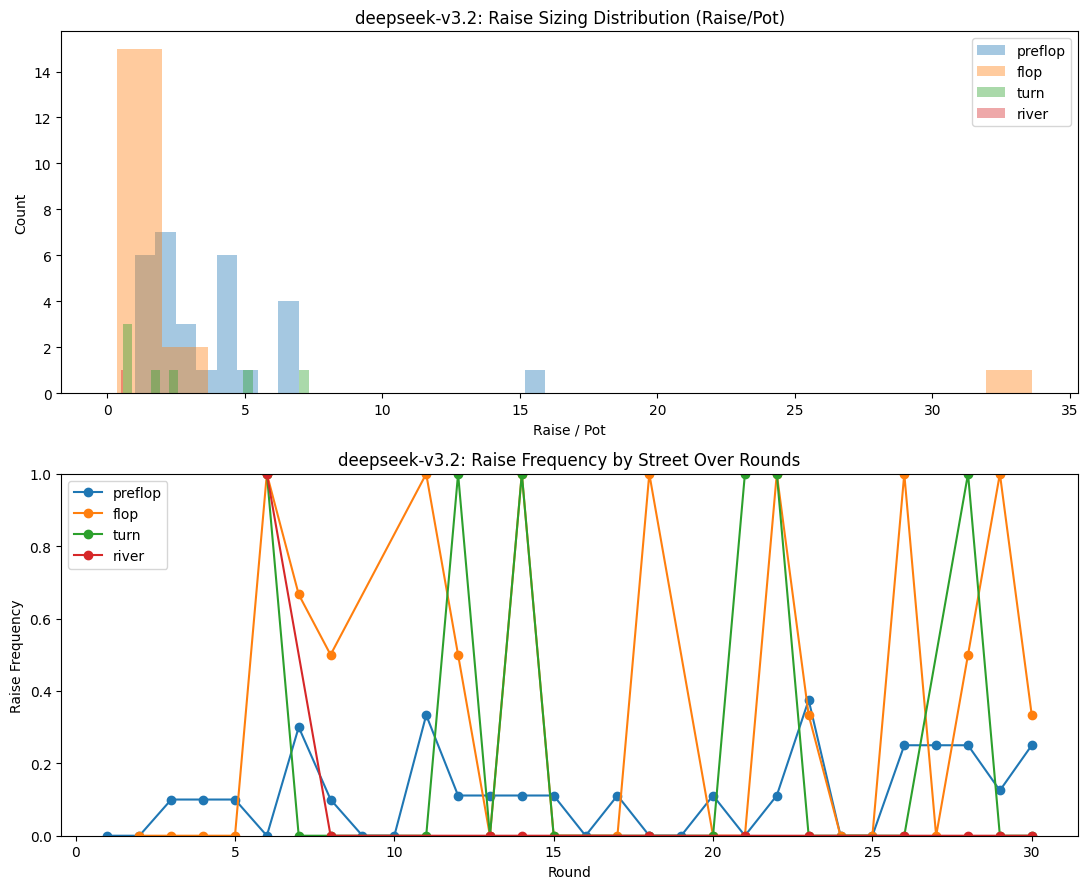


Saved one combined figure to: deepseek-v3.2_behavior_summary.pdf


In [2]:
import json
import math
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = "results.json"
TARGET = "Emily Zhang"  # The raw/original name you want to analyze

player_to_llm = {
    "Emily Zhang": "deepseek-v3.2",
    "Robert Garcia": "qwen3-32b",
    "Jessica Liu": "gemini-2.5-flash-lite",
    "Alex Chen": "gpt-4.1-mini",
    "Sarah Johnson": "llama-4-maverick",
    # "Michael Davis": "claude-3.5-haiku",
    "Niko Grey": "grok-3-mini",
    "Noah Kim": "loose passive bot",
    "Ava Park": "loose aggressive bot",
    "Noah Blake": "Maniac",
    "Lily Grant": "TightPassive",
    "Jade Park": "TightAggressive",
}

def safe_div(a, b):
    return a / b if b else 0.0

def display_name(raw_name: str) -> str:
    """Map a raw player/bot name to a human-readable model/style name."""
    if raw_name in player_to_llm:
        return player_to_llm[raw_name]
    return raw_name

def find_target_key(battles, target_name: str) -> str:
    """
    TARGET may be an old name (e.g., 'Ava Park') while JSON uses 'LAG Bot A'.
    Strategy:
      1) If TARGET is a key in players, use it directly
      2) Otherwise, use display_name(TARGET) and reverse-match a player key
         whose display_name(raw_key) equals it.
    """
    desired_display = display_name(target_name)

    for battle in battles:
        players = battle.get("players", {})
        if target_name in players:
            return target_name

        for raw in players.keys():
            if display_name(raw) == desired_display:
                return raw

    raise KeyError(f"Cannot find TARGET={target_name} (or mapped name={desired_display}) in players")

def extract_raise_amount(pack: dict) -> int | None:
    """
    In the new structure, action often lacks 'amount':
      action: {"action":"CALL"}  (no amount)
    Raise sizing may appear in reasoning text or opponent action strings:
      "RAISE to 15", "raise 150", etc.
    """
    # 1) action.amount (if present)
    act = pack.get("action") or {}
    if "amount" in act and act["amount"] is not None:
        try:
            return int(act["amount"])
        except:
            pass

    # 2) Parse from reasoning text
    reasoning = pack.get("reasoning", "") or ""
    m = re.search(r"RAISE\s*to\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"raise\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    # 3) Parse from opponent_actions strings (same street)
    gs = pack.get("game_state") or {}
    opp = (gs.get("opponent_actions") or {})
    street = str(gs.get("street", "")).lower()
    acts = opp.get(street, []) if isinstance(opp, dict) else []
    for item in reversed(acts):
        s = str(item.get("action", ""))
        m2 = re.search(r"RAISE\s*to\s*(\d+)", s, flags=re.IGNORECASE)
        if m2:
            return int(m2.group(1))

    return None


# =========================
# Load results.json
# =========================
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

battles = data.get("battles", [])
if not battles:
    raise ValueError("No 'battles' found in results.json")

# Auto-locate the true player key in the new structure (e.g., 'LAG Bot A')
TARGET_KEY = find_target_key(battles, TARGET)
TARGET_NAME = display_name(TARGET_KEY)


# =========================
# (1) Battle-level summary
# =========================
battle_rows = []
for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue

    p = players[TARGET_KEY]
    hands_played = p.get("hands_played", 0)
    hands_folded = p.get("hands_folded", 0)
    hands_called = p.get("hands_called", 0)
    hands_raised = p.get("hands_raised", 0)

    abs_ = p.get("actions_by_street", {})
    pre = abs_.get("preflop", {})
    flo = abs_.get("flop", {})
    tur = abs_.get("turn", {})
    riv = abs_.get("river", {})

    battle_rows.append({
        "battle_id": b_id,
        "hands_played": hands_played,
        "fold_rate_%": p.get("fold_rate", safe_div(hands_folded, hands_played) * 100),
        "call_rate_%": p.get("call_rate", safe_div(hands_called, hands_played) * 100),
        "raise_rate_%": p.get("raise_rate", safe_div(hands_raised, hands_played) * 100),
        "aggression_factor": p.get("aggression_factor", None),
        "profit": p.get("total_profit_loss", None),

        "preflop_raise": pre.get("raise", None),
        "preflop_call": pre.get("call", None),
        "preflop_fold": pre.get("fold", None),

        "flop_raise": flo.get("raise", None),
        "flop_call": flo.get("call", None),
        "flop_fold": flo.get("fold", None),

        "turn_raise": tur.get("raise", None),
        "turn_call": tur.get("call", None),
        "turn_fold": tur.get("fold", None),

        "river_raise": riv.get("raise", None),
        "river_call": riv.get("call", None),
        "river_fold": riv.get("fold", None),
    })

df_battle = pd.DataFrame(battle_rows)


# =========================
# (2) Rebuild per-hand/per-street actions + raise sizing from reasoning_history
# =========================
action_rows = []
size_rows = []

for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue
    p = players[TARGET_KEY]

    rh = p.get("reasoning_history", {})
    if not rh:
        continue

    for rnd_str, streets in rh.items():
        try:
            rnd = int(rnd_str)
        except:
            rnd = rnd_str

        for street, pack in (streets or {}).items():
            act_obj = pack.get("action") or {}
            act = act_obj.get("action", None)
            gs = pack.get("game_state") or {}

            pot = gs.get("pot_size", None)
            call_amt = gs.get("call_amount", None)
            min_raise = gs.get("min_raise", None)
            max_raise = gs.get("max_raise", None)
            hs = gs.get("env_hand_strength", gs.get("hand_strength", None))

            if act is None:
                continue

            # Amount fallback logic:
            # - CALL has no amount -> use call_amount
            # - FOLD -> 0
            # - RAISE -> parse from text / opponent actions if needed
            amt = act_obj.get("amount", None)
            if amt is None:
                if act == "CALL":
                    amt = 0 if (call_amt is None) else int(call_amt)
                elif act == "FOLD":
                    amt = 0
                elif act == "RAISE":
                    amt = extract_raise_amount(pack)

            action_rows.append({
                "battle_id": b_id,
                "round": rnd,
                "street": str(street).lower(),
                "action": act,
                "amount": amt,
                "pot_size": pot,
                "call_amount": call_amt,
                "min_raise": min_raise,
                "max_raise": max_raise,
                "hand_strength": hs
            })

            if act == "RAISE" and amt is not None and pot not in (None, 0):
                size_rows.append({
                    "battle_id": b_id,
                    "round": rnd,
                    "street": str(street).lower(),
                    "raise_amount": float(amt),
                    "pot_size": float(pot),
                    "raise_over_pot": float(amt) / float(pot),
                    "hand_strength": hs
                })

df_act = pd.DataFrame(action_rows)
df_size = pd.DataFrame(size_rows)

print("\n===== Street action counts =====")
if df_act.empty:
    print("No reasoning_history found.")
else:
    print(pd.crosstab(df_act["street"], df_act["action"]))

print("\n===== Raise sizing (raise/pot) summary =====")
if df_size.empty:
    print("No RAISE sizing data.")
else:
    print(df_size.groupby("street")["raise_over_pot"].describe())


# =========================
# (3) Behavioral metrics (VPIP/PFR/AF/big bet ratio)
# =========================
def compute_metrics(df_act, df_size):
    out = {}
    pre = df_act[df_act["street"].eq("preflop")].copy()

    # VPIP: put money voluntarily preflop (CALL/RAISE) with call_amount > 0
    pre_vpip = pre[(pre["action"].isin(["CALL", "RAISE"])) & (pre["call_amount"].fillna(0) > 0)]
    pre_pfr = pre[pre["action"].eq("RAISE")]

    out["hands_seen_preflop"] = len(pre)
    out["VPIP_%"] = safe_div(len(pre_vpip), len(pre)) * 100 if len(pre) else 0
    out["PFR_%"] = safe_div(len(pre_pfr), len(pre)) * 100 if len(pre) else 0

    for st in ["flop", "turn", "river"]:
        st_df = df_act[df_act["street"].eq(st)]
        r = (st_df["action"] == "RAISE").sum()
        c = (st_df["action"] == "CALL").sum()
        out[f"{st}_agg_factor"] = safe_div(r, c) if (r or c) else np.nan

    if not df_size.empty:
        out["big_bet_ratio_%(>=0.75pot)"] = (df_size["raise_over_pot"] >= 0.75).mean() * 100
        out["median_raise_over_pot"] = df_size["raise_over_pot"].median()
    else:
        out["big_bet_ratio_%(>=0.75pot)"] = np.nan
        out["median_raise_over_pot"] = np.nan

    return out

if not df_act.empty:
    metrics = compute_metrics(df_act, df_size)
    print(f"\n===== {TARGET_NAME} metrics (behavioral) =====")
    for k, v in metrics.items():
        ok = isinstance(v, (int, float)) and not (isinstance(v, float) and math.isnan(v))
        print(f"{k}: {v:.3f}" if ok else f"{k}: {v}")


# =========================
# (4) Output ONE image (single PNG)
#     - Top: raise sizing distribution (if available)
#     - Bottom: raise frequency by street over rounds (if available)
# =========================
OUT_PNG = f"{TARGET_NAME}_behavior_summary.pdf"

plots_available = []
has_size_plot = (not df_size.empty)
has_freq_plot = (not df_act.empty)

if not has_size_plot and not has_freq_plot:
    print("\nNo data to plot (both df_size and df_act are empty).")
else:
    nrows = int(has_size_plot) + int(has_freq_plot)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(11, 4.5 * nrows))
    if nrows == 1:
        axes = [axes]

    ax_i = 0

    # (A) Raise sizing histogram overlays by street
    if has_size_plot:
        ax = axes[ax_i]
        for st in ["preflop", "flop", "turn", "river"]:
            s = df_size[df_size["street"].eq(st)]["raise_over_pot"].dropna()
            if len(s) == 0:
                continue
            ax.hist(s, bins=20, alpha=0.4, label=st)
        ax.set_xlabel("Raise / Pot")
        ax.set_ylabel("Count")
        ax.set_title(f"{TARGET_NAME}: Raise Sizing Distribution (Raise/Pot)")
        ax.legend()
        ax_i += 1

    # (B) Raise frequency line by street over rounds
    if has_freq_plot:
        ax = axes[ax_i]
        tmp = df_act.copy()
        tmp["is_raise"] = (tmp["action"] == "RAISE").astype(int)
        g = tmp.groupby(["street", "round"])["is_raise"].mean().reset_index()

        for st in ["preflop", "flop", "turn", "river"]:
            sub = g[g["street"] == st]
            if sub.empty:
                continue
            ax.plot(sub["round"], sub["is_raise"], marker="o", label=st)

        ax.set_ylim(0, 1)
        ax.set_xlabel("Round")
        ax.set_ylabel("Raise Frequency")
        ax.set_title(f"{TARGET_NAME}: Raise Frequency by Street Over Rounds")
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"\nSaved one combined figure to: {OUT_PNG}")


===== Street action counts =====
action   CALL  FOLD  RAISE
street                    
flop       14    16      9
preflop    31   259     10
river       2     3      3
turn        4    10      6

===== Raise sizing (raise/pot) summary =====
         count      mean       std       min       25%       50%       75%  \
street                                                                       
flop       9.0  0.286677  0.280543  0.094340  0.142857  0.202020  0.285714   
preflop   10.0  1.261762  0.573040  0.600000  0.691071  1.260000  1.666667   
river      3.0  1.403784  1.988149  0.117647  0.258824  0.400000  2.046853   
turn       6.0  0.121435  0.073408  0.014388  0.078957  0.124542  0.174825   

              max  
street             
flop     1.000000  
preflop  2.000000  
river    3.693706  
turn     0.209790  

===== qwen3-32b metrics (behavioral) =====
hands_seen_preflop: 300.000
VPIP_%: 12.667
PFR_%: 3.333
flop_agg_factor: 0.643
turn_agg_factor: 1.500
river_agg_factor: 1.500

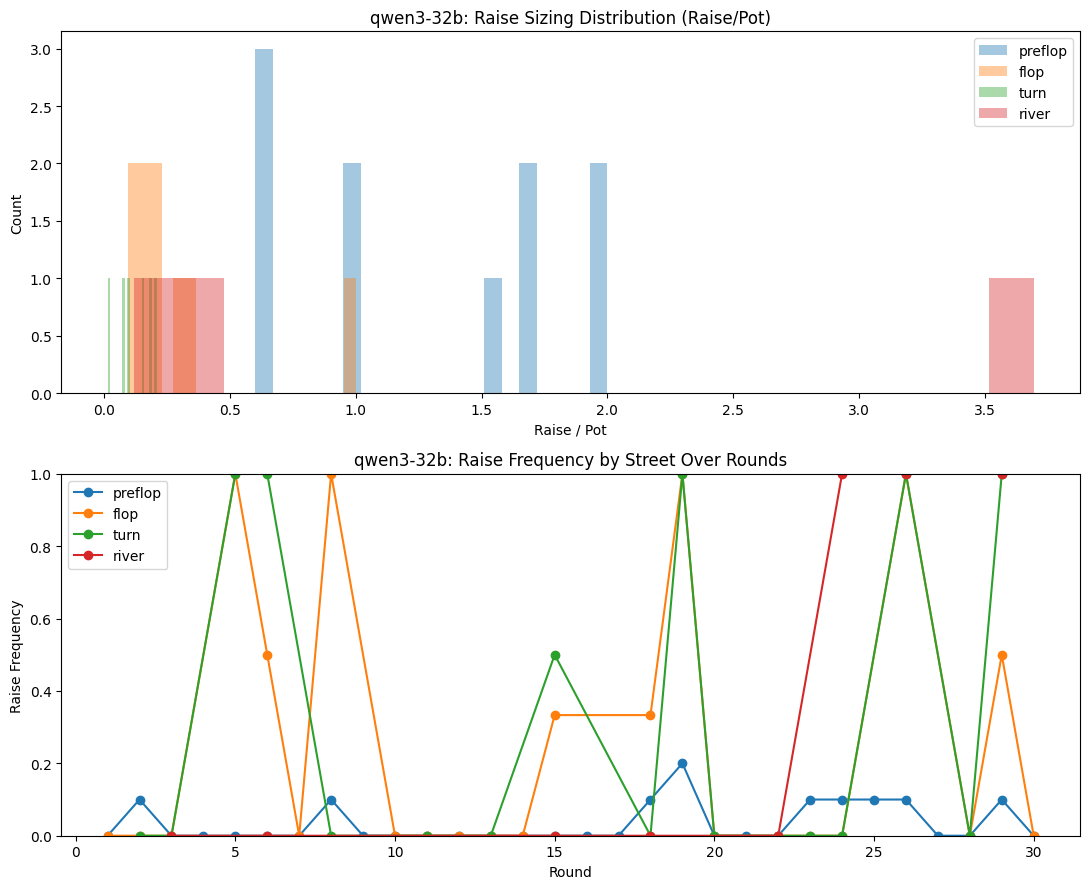


Saved one combined figure to: qwen3-32b_behavior_summary.pdf


In [3]:
import json
import math
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = "results.json"
TARGET = "Robert Garcia"  # The raw/original name you want to analyze

player_to_llm = {
    "Emily Zhang": "deepseek-v3.2",
    "Robert Garcia": "qwen3-32b",
    "Jessica Liu": "gemini-2.5-flash-lite",
    "Alex Chen": "gpt-4.1-mini",
    "Sarah Johnson": "llama-4-maverick",
    # "Michael Davis": "claude-3.5-haiku",
    "Niko Grey": "grok-3-mini",
    "Noah Kim": "loose passive bot",
    "Ava Park": "loose aggressive bot",
    "Noah Blake": "Maniac",
    "Lily Grant": "TightPassive",
    "Jade Park": "TightAggressive",
}

def safe_div(a, b):
    return a / b if b else 0.0

def display_name(raw_name: str) -> str:
    """Map a raw player/bot name to a human-readable model/style name."""
    if raw_name in player_to_llm:
        return player_to_llm[raw_name]

    return raw_name

def find_target_key(battles, target_name: str) -> str:
    """
    TARGET may be an old name (e.g., 'Ava Park') while JSON uses 'LAG Bot A'.
    Strategy:
      1) If TARGET is a key in players, use it directly
      2) Otherwise, use display_name(TARGET) and reverse-match a player key
         whose display_name(raw_key) equals it.
    """
    desired_display = display_name(target_name)

    for battle in battles:
        players = battle.get("players", {})
        if target_name in players:
            return target_name

        for raw in players.keys():
            if display_name(raw) == desired_display:
                return raw

    raise KeyError(f"Cannot find TARGET={target_name} (or mapped name={desired_display}) in players")

def extract_raise_amount(pack: dict) -> int | None:
    """
    In the new structure, action often lacks 'amount':
      action: {"action":"CALL"}  (no amount)
    Raise sizing may appear in reasoning text or opponent action strings:
      "RAISE to 15", "raise 150", etc.
    """
    # 1) action.amount (if present)
    act = pack.get("action") or {}
    if "amount" in act and act["amount"] is not None:
        try:
            return int(act["amount"])
        except:
            pass

    # 2) Parse from reasoning text
    reasoning = pack.get("reasoning", "") or ""
    m = re.search(r"RAISE\s*to\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"raise\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    # 3) Parse from opponent_actions strings (same street)
    gs = pack.get("game_state") or {}
    opp = (gs.get("opponent_actions") or {})
    street = str(gs.get("street", "")).lower()
    acts = opp.get(street, []) if isinstance(opp, dict) else []
    for item in reversed(acts):
        s = str(item.get("action", ""))
        m2 = re.search(r"RAISE\s*to\s*(\d+)", s, flags=re.IGNORECASE)
        if m2:
            return int(m2.group(1))

    return None


# =========================
# Load results.json
# =========================
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

battles = data.get("battles", [])
if not battles:
    raise ValueError("No 'battles' found in results.json")

# Auto-locate the true player key in the new structure (e.g., 'LAG Bot A')
TARGET_KEY = find_target_key(battles, TARGET)
TARGET_NAME = display_name(TARGET_KEY)


# =========================
# (1) Battle-level summary
# =========================
battle_rows = []
for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue

    p = players[TARGET_KEY]
    hands_played = p.get("hands_played", 0)
    hands_folded = p.get("hands_folded", 0)
    hands_called = p.get("hands_called", 0)
    hands_raised = p.get("hands_raised", 0)

    abs_ = p.get("actions_by_street", {})
    pre = abs_.get("preflop", {})
    flo = abs_.get("flop", {})
    tur = abs_.get("turn", {})
    riv = abs_.get("river", {})

    battle_rows.append({
        "battle_id": b_id,
        "hands_played": hands_played,
        "fold_rate_%": p.get("fold_rate", safe_div(hands_folded, hands_played) * 100),
        "call_rate_%": p.get("call_rate", safe_div(hands_called, hands_played) * 100),
        "raise_rate_%": p.get("raise_rate", safe_div(hands_raised, hands_played) * 100),
        "aggression_factor": p.get("aggression_factor", None),
        "profit": p.get("total_profit_loss", None),

        "preflop_raise": pre.get("raise", None),
        "preflop_call": pre.get("call", None),
        "preflop_fold": pre.get("fold", None),

        "flop_raise": flo.get("raise", None),
        "flop_call": flo.get("call", None),
        "flop_fold": flo.get("fold", None),

        "turn_raise": tur.get("raise", None),
        "turn_call": tur.get("call", None),
        "turn_fold": tur.get("fold", None),

        "river_raise": riv.get("raise", None),
        "river_call": riv.get("call", None),
        "river_fold": riv.get("fold", None),
    })

df_battle = pd.DataFrame(battle_rows)


# =========================
# (2) Rebuild per-hand/per-street actions + raise sizing from reasoning_history
# =========================
action_rows = []
size_rows = []

for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue
    p = players[TARGET_KEY]

    rh = p.get("reasoning_history", {})
    if not rh:
        continue

    for rnd_str, streets in rh.items():
        try:
            rnd = int(rnd_str)
        except:
            rnd = rnd_str

        for street, pack in (streets or {}).items():
            act_obj = pack.get("action") or {}
            act = act_obj.get("action", None)
            gs = pack.get("game_state") or {}

            pot = gs.get("pot_size", None)
            call_amt = gs.get("call_amount", None)
            min_raise = gs.get("min_raise", None)
            max_raise = gs.get("max_raise", None)
            hs = gs.get("env_hand_strength", gs.get("hand_strength", None))

            if act is None:
                continue

            # Amount fallback logic:
            # - CALL has no amount -> use call_amount
            # - FOLD -> 0
            # - RAISE -> parse from text / opponent actions if needed
            amt = act_obj.get("amount", None)
            if amt is None:
                if act == "CALL":
                    amt = 0 if (call_amt is None) else int(call_amt)
                elif act == "FOLD":
                    amt = 0
                elif act == "RAISE":
                    amt = extract_raise_amount(pack)

            action_rows.append({
                "battle_id": b_id,
                "round": rnd,
                "street": str(street).lower(),
                "action": act,
                "amount": amt,
                "pot_size": pot,
                "call_amount": call_amt,
                "min_raise": min_raise,
                "max_raise": max_raise,
                "hand_strength": hs
            })

            if act == "RAISE" and amt is not None and pot not in (None, 0):
                size_rows.append({
                    "battle_id": b_id,
                    "round": rnd,
                    "street": str(street).lower(),
                    "raise_amount": float(amt),
                    "pot_size": float(pot),
                    "raise_over_pot": float(amt) / float(pot),
                    "hand_strength": hs
                })

df_act = pd.DataFrame(action_rows)
df_size = pd.DataFrame(size_rows)

print("\n===== Street action counts =====")
if df_act.empty:
    print("No reasoning_history found.")
else:
    print(pd.crosstab(df_act["street"], df_act["action"]))

print("\n===== Raise sizing (raise/pot) summary =====")
if df_size.empty:
    print("No RAISE sizing data.")
else:
    print(df_size.groupby("street")["raise_over_pot"].describe())


# =========================
# (3) Behavioral metrics (VPIP/PFR/AF/big bet ratio)
# =========================
def compute_metrics(df_act, df_size):
    out = {}
    pre = df_act[df_act["street"].eq("preflop")].copy()

    # VPIP: put money voluntarily preflop (CALL/RAISE) with call_amount > 0
    pre_vpip = pre[(pre["action"].isin(["CALL", "RAISE"])) & (pre["call_amount"].fillna(0) > 0)]
    pre_pfr = pre[pre["action"].eq("RAISE")]

    out["hands_seen_preflop"] = len(pre)
    out["VPIP_%"] = safe_div(len(pre_vpip), len(pre)) * 100 if len(pre) else 0
    out["PFR_%"] = safe_div(len(pre_pfr), len(pre)) * 100 if len(pre) else 0

    for st in ["flop", "turn", "river"]:
        st_df = df_act[df_act["street"].eq(st)]
        r = (st_df["action"] == "RAISE").sum()
        c = (st_df["action"] == "CALL").sum()
        out[f"{st}_agg_factor"] = safe_div(r, c) if (r or c) else np.nan

    if not df_size.empty:
        out["big_bet_ratio_%(>=0.75pot)"] = (df_size["raise_over_pot"] >= 0.75).mean() * 100
        out["median_raise_over_pot"] = df_size["raise_over_pot"].median()
    else:
        out["big_bet_ratio_%(>=0.75pot)"] = np.nan
        out["median_raise_over_pot"] = np.nan

    return out

if not df_act.empty:
    metrics = compute_metrics(df_act, df_size)
    print(f"\n===== {TARGET_NAME} metrics (behavioral) =====")
    for k, v in metrics.items():
        ok = isinstance(v, (int, float)) and not (isinstance(v, float) and math.isnan(v))
        print(f"{k}: {v:.3f}" if ok else f"{k}: {v}")


# =========================
# (4) Output ONE image (single PNG)
#     - Top: raise sizing distribution (if available)
#     - Bottom: raise frequency by street over rounds (if available)
# =========================
OUT_PNG = f"{TARGET_NAME}_behavior_summary.pdf"

plots_available = []
has_size_plot = (not df_size.empty)
has_freq_plot = (not df_act.empty)

if not has_size_plot and not has_freq_plot:
    print("\nNo data to plot (both df_size and df_act are empty).")
else:
    nrows = int(has_size_plot) + int(has_freq_plot)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(11, 4.5 * nrows))
    if nrows == 1:
        axes = [axes]

    ax_i = 0

    # (A) Raise sizing histogram overlays by street
    if has_size_plot:
        ax = axes[ax_i]
        for st in ["preflop", "flop", "turn", "river"]:
            s = df_size[df_size["street"].eq(st)]["raise_over_pot"].dropna()
            if len(s) == 0:
                continue
            ax.hist(s, bins=20, alpha=0.4, label=st)
        ax.set_xlabel("Raise / Pot")
        ax.set_ylabel("Count")
        ax.set_title(f"{TARGET_NAME}: Raise Sizing Distribution (Raise/Pot)")
        ax.legend()
        ax_i += 1

    # (B) Raise frequency line by street over rounds
    if has_freq_plot:
        ax = axes[ax_i]
        tmp = df_act.copy()
        tmp["is_raise"] = (tmp["action"] == "RAISE").astype(int)
        g = tmp.groupby(["street", "round"])["is_raise"].mean().reset_index()

        for st in ["preflop", "flop", "turn", "river"]:
            sub = g[g["street"] == st]
            if sub.empty:
                continue
            ax.plot(sub["round"], sub["is_raise"], marker="o", label=st)

        ax.set_ylim(0, 1)
        ax.set_xlabel("Round")
        ax.set_ylabel("Raise Frequency")
        ax.set_title(f"{TARGET_NAME}: Raise Frequency by Street Over Rounds")
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"\nSaved one combined figure to: {OUT_PNG}")


===== Street action counts =====
action   CALL  FOLD  RAISE
street                    
flop       13     4     23
preflop    22   220     21
river       8     2      2
turn       10     1     18

===== Raise sizing (raise/pot) summary =====
         count      mean       std       min       25%       50%       75%  \
street                                                                       
flop      23.0  2.547296  4.269733  0.322581  0.960553  1.000000  1.937500   
preflop   21.0  3.119943  1.206332  1.250000  2.000000  3.333333  4.000000   
river      2.0  5.093571  5.198168  1.417910  3.255741  5.093571  6.931401   
turn      18.0  2.451136  2.393436  0.394737  0.827273  1.081871  3.744208   

               max  
street              
flop     16.166667  
preflop   5.000000  
river     8.769231  
turn      7.807547  

===== gemini-2.5-flash-lite metrics (behavioral) =====
hands_seen_preflop: 263.000
VPIP_%: 16.350
PFR_%: 7.985
flop_agg_factor: 1.769
turn_agg_factor: 1.800
river

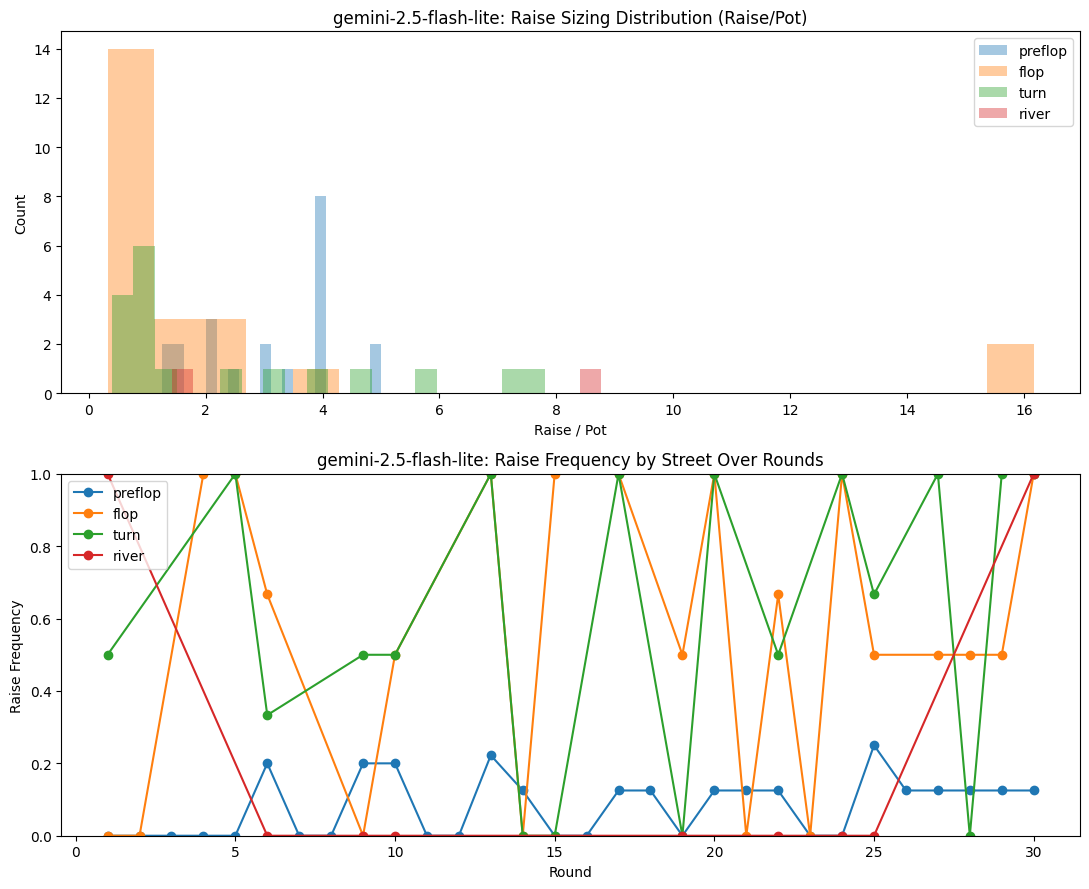


Saved one combined figure to: gemini-2.5-flash-lite_behavior_summary.pdf


In [4]:
import json
import math
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = "results.json"
TARGET = "Jessica Liu"  # The raw/original name you want to analyze

player_to_llm = {
    "Emily Zhang": "deepseek-v3.2",
    "Robert Garcia": "qwen3-32b",
    "Jessica Liu": "gemini-2.5-flash-lite",
    "Alex Chen": "gpt-4.1-mini",
    "Sarah Johnson": "llama-4-maverick",
    # "Michael Davis": "claude-3.5-haiku",
    "Niko Grey": "grok-3-mini",
    "Noah Kim": "loose passive bot",
    "Ava Park": "loose aggressive bot",
    "Noah Blake": "Maniac",
    "Lily Grant": "TightPassive",
    "Jade Park": "TightAggressive",
}

def safe_div(a, b):
    return a / b if b else 0.0

def display_name(raw_name: str) -> str:
    """Map a raw player/bot name to a human-readable model/style name."""
    if raw_name in player_to_llm:
        return player_to_llm[raw_name]
    return raw_name

def find_target_key(battles, target_name: str) -> str:
    """
    TARGET may be an old name (e.g., 'Ava Park') while JSON uses 'LAG Bot A'.
    Strategy:
      1) If TARGET is a key in players, use it directly
      2) Otherwise, use display_name(TARGET) and reverse-match a player key
         whose display_name(raw_key) equals it.
    """
    desired_display = display_name(target_name)

    for battle in battles:
        players = battle.get("players", {})
        if target_name in players:
            return target_name

        for raw in players.keys():
            if display_name(raw) == desired_display:
                return raw

    raise KeyError(f"Cannot find TARGET={target_name} (or mapped name={desired_display}) in players")

def extract_raise_amount(pack: dict) -> int | None:
    """
    In the new structure, action often lacks 'amount':
      action: {"action":"CALL"}  (no amount)
    Raise sizing may appear in reasoning text or opponent action strings:
      "RAISE to 15", "raise 150", etc.
    """
    # 1) action.amount (if present)
    act = pack.get("action") or {}
    if "amount" in act and act["amount"] is not None:
        try:
            return int(act["amount"])
        except:
            pass

    # 2) Parse from reasoning text
    reasoning = pack.get("reasoning", "") or ""
    m = re.search(r"RAISE\s*to\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"raise\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    # 3) Parse from opponent_actions strings (same street)
    gs = pack.get("game_state") or {}
    opp = (gs.get("opponent_actions") or {})
    street = str(gs.get("street", "")).lower()
    acts = opp.get(street, []) if isinstance(opp, dict) else []
    for item in reversed(acts):
        s = str(item.get("action", ""))
        m2 = re.search(r"RAISE\s*to\s*(\d+)", s, flags=re.IGNORECASE)
        if m2:
            return int(m2.group(1))

    return None


# =========================
# Load results.json
# =========================
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

battles = data.get("battles", [])
if not battles:
    raise ValueError("No 'battles' found in results.json")

# Auto-locate the true player key in the new structure (e.g., 'LAG Bot A')
TARGET_KEY = find_target_key(battles, TARGET)
TARGET_NAME = display_name(TARGET_KEY)


# =========================
# (1) Battle-level summary
# =========================
battle_rows = []
for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue

    p = players[TARGET_KEY]
    hands_played = p.get("hands_played", 0)
    hands_folded = p.get("hands_folded", 0)
    hands_called = p.get("hands_called", 0)
    hands_raised = p.get("hands_raised", 0)

    abs_ = p.get("actions_by_street", {})
    pre = abs_.get("preflop", {})
    flo = abs_.get("flop", {})
    tur = abs_.get("turn", {})
    riv = abs_.get("river", {})

    battle_rows.append({
        "battle_id": b_id,
        "hands_played": hands_played,
        "fold_rate_%": p.get("fold_rate", safe_div(hands_folded, hands_played) * 100),
        "call_rate_%": p.get("call_rate", safe_div(hands_called, hands_played) * 100),
        "raise_rate_%": p.get("raise_rate", safe_div(hands_raised, hands_played) * 100),
        "aggression_factor": p.get("aggression_factor", None),
        "profit": p.get("total_profit_loss", None),

        "preflop_raise": pre.get("raise", None),
        "preflop_call": pre.get("call", None),
        "preflop_fold": pre.get("fold", None),

        "flop_raise": flo.get("raise", None),
        "flop_call": flo.get("call", None),
        "flop_fold": flo.get("fold", None),

        "turn_raise": tur.get("raise", None),
        "turn_call": tur.get("call", None),
        "turn_fold": tur.get("fold", None),

        "river_raise": riv.get("raise", None),
        "river_call": riv.get("call", None),
        "river_fold": riv.get("fold", None),
    })

df_battle = pd.DataFrame(battle_rows)


# =========================
# (2) Rebuild per-hand/per-street actions + raise sizing from reasoning_history
# =========================
action_rows = []
size_rows = []

for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue
    p = players[TARGET_KEY]

    rh = p.get("reasoning_history", {})
    if not rh:
        continue

    for rnd_str, streets in rh.items():
        try:
            rnd = int(rnd_str)
        except:
            rnd = rnd_str

        for street, pack in (streets or {}).items():
            act_obj = pack.get("action") or {}
            act = act_obj.get("action", None)
            gs = pack.get("game_state") or {}

            pot = gs.get("pot_size", None)
            call_amt = gs.get("call_amount", None)
            min_raise = gs.get("min_raise", None)
            max_raise = gs.get("max_raise", None)
            hs = gs.get("env_hand_strength", gs.get("hand_strength", None))

            if act is None:
                continue

            # Amount fallback logic:
            # - CALL has no amount -> use call_amount
            # - FOLD -> 0
            # - RAISE -> parse from text / opponent actions if needed
            amt = act_obj.get("amount", None)
            if amt is None:
                if act == "CALL":
                    amt = 0 if (call_amt is None) else int(call_amt)
                elif act == "FOLD":
                    amt = 0
                elif act == "RAISE":
                    amt = extract_raise_amount(pack)

            action_rows.append({
                "battle_id": b_id,
                "round": rnd,
                "street": str(street).lower(),
                "action": act,
                "amount": amt,
                "pot_size": pot,
                "call_amount": call_amt,
                "min_raise": min_raise,
                "max_raise": max_raise,
                "hand_strength": hs
            })

            if act == "RAISE" and amt is not None and pot not in (None, 0):
                size_rows.append({
                    "battle_id": b_id,
                    "round": rnd,
                    "street": str(street).lower(),
                    "raise_amount": float(amt),
                    "pot_size": float(pot),
                    "raise_over_pot": float(amt) / float(pot),
                    "hand_strength": hs
                })

df_act = pd.DataFrame(action_rows)
df_size = pd.DataFrame(size_rows)

print("\n===== Street action counts =====")
if df_act.empty:
    print("No reasoning_history found.")
else:
    print(pd.crosstab(df_act["street"], df_act["action"]))

print("\n===== Raise sizing (raise/pot) summary =====")
if df_size.empty:
    print("No RAISE sizing data.")
else:
    print(df_size.groupby("street")["raise_over_pot"].describe())


# =========================
# (3) Behavioral metrics (VPIP/PFR/AF/big bet ratio)
# =========================
def compute_metrics(df_act, df_size):
    out = {}
    pre = df_act[df_act["street"].eq("preflop")].copy()

    # VPIP: put money voluntarily preflop (CALL/RAISE) with call_amount > 0
    pre_vpip = pre[(pre["action"].isin(["CALL", "RAISE"])) & (pre["call_amount"].fillna(0) > 0)]
    pre_pfr = pre[pre["action"].eq("RAISE")]

    out["hands_seen_preflop"] = len(pre)
    out["VPIP_%"] = safe_div(len(pre_vpip), len(pre)) * 100 if len(pre) else 0
    out["PFR_%"] = safe_div(len(pre_pfr), len(pre)) * 100 if len(pre) else 0

    for st in ["flop", "turn", "river"]:
        st_df = df_act[df_act["street"].eq(st)]
        r = (st_df["action"] == "RAISE").sum()
        c = (st_df["action"] == "CALL").sum()
        out[f"{st}_agg_factor"] = safe_div(r, c) if (r or c) else np.nan

    if not df_size.empty:
        out["big_bet_ratio_%(>=0.75pot)"] = (df_size["raise_over_pot"] >= 0.75).mean() * 100
        out["median_raise_over_pot"] = df_size["raise_over_pot"].median()
    else:
        out["big_bet_ratio_%(>=0.75pot)"] = np.nan
        out["median_raise_over_pot"] = np.nan

    return out

if not df_act.empty:
    metrics = compute_metrics(df_act, df_size)
    print(f"\n===== {TARGET_NAME} metrics (behavioral) =====")
    for k, v in metrics.items():
        ok = isinstance(v, (int, float)) and not (isinstance(v, float) and math.isnan(v))
        print(f"{k}: {v:.3f}" if ok else f"{k}: {v}")


# =========================
# (4) Output ONE image (single PNG)
#     - Top: raise sizing distribution (if available)
#     - Bottom: raise frequency by street over rounds (if available)
# =========================
OUT_PNG = f"{TARGET_NAME}_behavior_summary.pdf"

plots_available = []
has_size_plot = (not df_size.empty)
has_freq_plot = (not df_act.empty)

if not has_size_plot and not has_freq_plot:
    print("\nNo data to plot (both df_size and df_act are empty).")
else:
    nrows = int(has_size_plot) + int(has_freq_plot)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(11, 4.5 * nrows))
    if nrows == 1:
        axes = [axes]

    ax_i = 0

    # (A) Raise sizing histogram overlays by street
    if has_size_plot:
        ax = axes[ax_i]
        for st in ["preflop", "flop", "turn", "river"]:
            s = df_size[df_size["street"].eq(st)]["raise_over_pot"].dropna()
            if len(s) == 0:
                continue
            ax.hist(s, bins=20, alpha=0.4, label=st)
        ax.set_xlabel("Raise / Pot")
        ax.set_ylabel("Count")
        ax.set_title(f"{TARGET_NAME}: Raise Sizing Distribution (Raise/Pot)")
        ax.legend()
        ax_i += 1

    # (B) Raise frequency line by street over rounds
    if has_freq_plot:
        ax = axes[ax_i]
        tmp = df_act.copy()
        tmp["is_raise"] = (tmp["action"] == "RAISE").astype(int)
        g = tmp.groupby(["street", "round"])["is_raise"].mean().reset_index()

        for st in ["preflop", "flop", "turn", "river"]:
            sub = g[g["street"] == st]
            if sub.empty:
                continue
            ax.plot(sub["round"], sub["is_raise"], marker="o", label=st)

        ax.set_ylim(0, 1)
        ax.set_xlabel("Round")
        ax.set_ylabel("Raise Frequency")
        ax.set_title(f"{TARGET_NAME}: Raise Frequency by Street Over Rounds")
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"\nSaved one combined figure to: {OUT_PNG}")


===== Street action counts =====
action   CALL  FOLD  RAISE
street                    
flop       36    24     28
preflop    58   172     33
river      18     5     13
turn       20    16     23

===== Raise sizing (raise/pot) summary =====
         count      mean        std       min       25%       50%       75%  \
street                                                                        
flop      28.0  1.425535   4.435567  0.300000  0.443627  0.533428  0.687500   
preflop   33.0  1.451609   0.583441  0.627907  1.000000  1.200000  1.960784   
river     13.0  1.193168   1.631309  0.344886  0.520833  0.649351  0.685714   
turn      23.0  4.571634  15.993729  0.330579  0.500000  0.571429  0.720779   

               max  
street              
flop     24.030000  
preflop   2.666667  
river     6.112195  
turn     77.466667  

===== llama-4-maverick metrics (behavioral) =====
hands_seen_preflop: 263.000
VPIP_%: 32.700
PFR_%: 12.548
flop_agg_factor: 0.778
turn_agg_factor: 1.150
riv

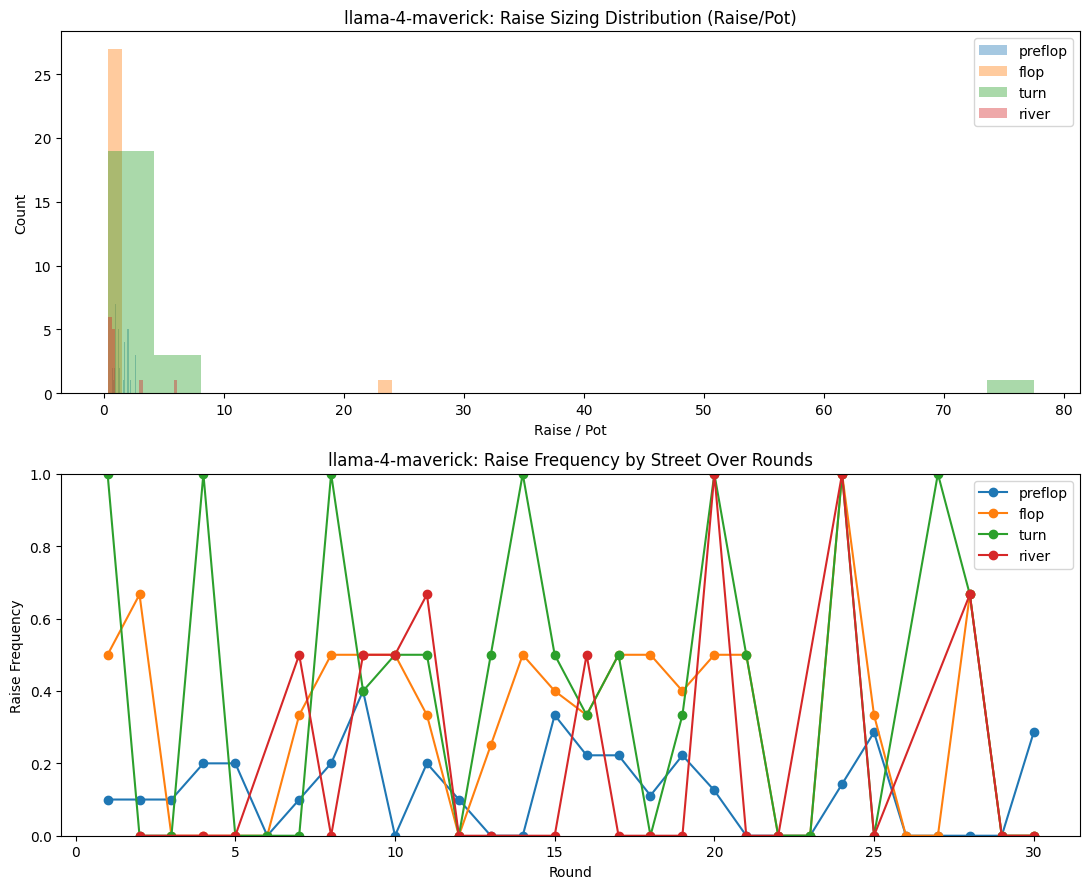


Saved one combined figure to: llama-4-maverick_behavior_summary.pdf


In [5]:
import json
import math
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = "results.json"
TARGET = "Sarah Johnson"  # The raw/original name you want to analyze

player_to_llm = {
    "Emily Zhang": "deepseek-v3.2",
    "Robert Garcia": "qwen3-32b",
    "Jessica Liu": "gemini-2.5-flash-lite",
    "Alex Chen": "gpt-4.1-mini",
    "Sarah Johnson": "llama-4-maverick",
    # "Michael Davis": "claude-3.5-haiku",
    "Niko Grey": "grok-3-mini",
    "Noah Kim": "loose passive bot",
    "Ava Park": "loose aggressive bot",
    "Noah Blake": "Maniac",
    "Lily Grant": "TightPassive",
    "Jade Park": "TightAggressive",
}

def safe_div(a, b):
    return a / b if b else 0.0

def display_name(raw_name: str) -> str:
    """Map a raw player/bot name to a human-readable model/style name."""
    if raw_name in player_to_llm:
        return player_to_llm[raw_name]
    return raw_name

def find_target_key(battles, target_name: str) -> str:
    """
    TARGET may be an old name (e.g., 'Ava Park') while JSON uses 'LAG Bot A'.
    Strategy:
      1) If TARGET is a key in players, use it directly
      2) Otherwise, use display_name(TARGET) and reverse-match a player key
         whose display_name(raw_key) equals it.
    """
    desired_display = display_name(target_name)

    for battle in battles:
        players = battle.get("players", {})
        if target_name in players:
            return target_name

        for raw in players.keys():
            if display_name(raw) == desired_display:
                return raw

    raise KeyError(f"Cannot find TARGET={target_name} (or mapped name={desired_display}) in players")

def extract_raise_amount(pack: dict) -> int | None:
    """
    In the new structure, action often lacks 'amount':
      action: {"action":"CALL"}  (no amount)
    Raise sizing may appear in reasoning text or opponent action strings:
      "RAISE to 15", "raise 150", etc.
    """
    # 1) action.amount (if present)
    act = pack.get("action") or {}
    if "amount" in act and act["amount"] is not None:
        try:
            return int(act["amount"])
        except:
            pass

    # 2) Parse from reasoning text
    reasoning = pack.get("reasoning", "") or ""
    m = re.search(r"RAISE\s*to\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"raise\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    # 3) Parse from opponent_actions strings (same street)
    gs = pack.get("game_state") or {}
    opp = (gs.get("opponent_actions") or {})
    street = str(gs.get("street", "")).lower()
    acts = opp.get(street, []) if isinstance(opp, dict) else []
    for item in reversed(acts):
        s = str(item.get("action", ""))
        m2 = re.search(r"RAISE\s*to\s*(\d+)", s, flags=re.IGNORECASE)
        if m2:
            return int(m2.group(1))

    return None


# =========================
# Load results.json
# =========================
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

battles = data.get("battles", [])
if not battles:
    raise ValueError("No 'battles' found in results.json")

# Auto-locate the true player key in the new structure (e.g., 'LAG Bot A')
TARGET_KEY = find_target_key(battles, TARGET)
TARGET_NAME = display_name(TARGET_KEY)


# =========================
# (1) Battle-level summary
# =========================
battle_rows = []
for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue

    p = players[TARGET_KEY]
    hands_played = p.get("hands_played", 0)
    hands_folded = p.get("hands_folded", 0)
    hands_called = p.get("hands_called", 0)
    hands_raised = p.get("hands_raised", 0)

    abs_ = p.get("actions_by_street", {})
    pre = abs_.get("preflop", {})
    flo = abs_.get("flop", {})
    tur = abs_.get("turn", {})
    riv = abs_.get("river", {})

    battle_rows.append({
        "battle_id": b_id,
        "hands_played": hands_played,
        "fold_rate_%": p.get("fold_rate", safe_div(hands_folded, hands_played) * 100),
        "call_rate_%": p.get("call_rate", safe_div(hands_called, hands_played) * 100),
        "raise_rate_%": p.get("raise_rate", safe_div(hands_raised, hands_played) * 100),
        "aggression_factor": p.get("aggression_factor", None),
        "profit": p.get("total_profit_loss", None),

        "preflop_raise": pre.get("raise", None),
        "preflop_call": pre.get("call", None),
        "preflop_fold": pre.get("fold", None),

        "flop_raise": flo.get("raise", None),
        "flop_call": flo.get("call", None),
        "flop_fold": flo.get("fold", None),

        "turn_raise": tur.get("raise", None),
        "turn_call": tur.get("call", None),
        "turn_fold": tur.get("fold", None),

        "river_raise": riv.get("raise", None),
        "river_call": riv.get("call", None),
        "river_fold": riv.get("fold", None),
    })

df_battle = pd.DataFrame(battle_rows)


# =========================
# (2) Rebuild per-hand/per-street actions + raise sizing from reasoning_history
# =========================
action_rows = []
size_rows = []

for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue
    p = players[TARGET_KEY]

    rh = p.get("reasoning_history", {})
    if not rh:
        continue

    for rnd_str, streets in rh.items():
        try:
            rnd = int(rnd_str)
        except:
            rnd = rnd_str

        for street, pack in (streets or {}).items():
            act_obj = pack.get("action") or {}
            act = act_obj.get("action", None)
            gs = pack.get("game_state") or {}

            pot = gs.get("pot_size", None)
            call_amt = gs.get("call_amount", None)
            min_raise = gs.get("min_raise", None)
            max_raise = gs.get("max_raise", None)
            hs = gs.get("env_hand_strength", gs.get("hand_strength", None))

            if act is None:
                continue

            # Amount fallback logic:
            # - CALL has no amount -> use call_amount
            # - FOLD -> 0
            # - RAISE -> parse from text / opponent actions if needed
            amt = act_obj.get("amount", None)
            if amt is None:
                if act == "CALL":
                    amt = 0 if (call_amt is None) else int(call_amt)
                elif act == "FOLD":
                    amt = 0
                elif act == "RAISE":
                    amt = extract_raise_amount(pack)

            action_rows.append({
                "battle_id": b_id,
                "round": rnd,
                "street": str(street).lower(),
                "action": act,
                "amount": amt,
                "pot_size": pot,
                "call_amount": call_amt,
                "min_raise": min_raise,
                "max_raise": max_raise,
                "hand_strength": hs
            })

            if act == "RAISE" and amt is not None and pot not in (None, 0):
                size_rows.append({
                    "battle_id": b_id,
                    "round": rnd,
                    "street": str(street).lower(),
                    "raise_amount": float(amt),
                    "pot_size": float(pot),
                    "raise_over_pot": float(amt) / float(pot),
                    "hand_strength": hs
                })

df_act = pd.DataFrame(action_rows)
df_size = pd.DataFrame(size_rows)

print("\n===== Street action counts =====")
if df_act.empty:
    print("No reasoning_history found.")
else:
    print(pd.crosstab(df_act["street"], df_act["action"]))

print("\n===== Raise sizing (raise/pot) summary =====")
if df_size.empty:
    print("No RAISE sizing data.")
else:
    print(df_size.groupby("street")["raise_over_pot"].describe())


# =========================
# (3) Behavioral metrics (VPIP/PFR/AF/big bet ratio)
# =========================
def compute_metrics(df_act, df_size):
    out = {}
    pre = df_act[df_act["street"].eq("preflop")].copy()

    # VPIP: put money voluntarily preflop (CALL/RAISE) with call_amount > 0
    pre_vpip = pre[(pre["action"].isin(["CALL", "RAISE"])) & (pre["call_amount"].fillna(0) > 0)]
    pre_pfr = pre[pre["action"].eq("RAISE")]

    out["hands_seen_preflop"] = len(pre)
    out["VPIP_%"] = safe_div(len(pre_vpip), len(pre)) * 100 if len(pre) else 0
    out["PFR_%"] = safe_div(len(pre_pfr), len(pre)) * 100 if len(pre) else 0

    for st in ["flop", "turn", "river"]:
        st_df = df_act[df_act["street"].eq(st)]
        r = (st_df["action"] == "RAISE").sum()
        c = (st_df["action"] == "CALL").sum()
        out[f"{st}_agg_factor"] = safe_div(r, c) if (r or c) else np.nan

    if not df_size.empty:
        out["big_bet_ratio_%(>=0.75pot)"] = (df_size["raise_over_pot"] >= 0.75).mean() * 100
        out["median_raise_over_pot"] = df_size["raise_over_pot"].median()
    else:
        out["big_bet_ratio_%(>=0.75pot)"] = np.nan
        out["median_raise_over_pot"] = np.nan

    return out

if not df_act.empty:
    metrics = compute_metrics(df_act, df_size)
    print(f"\n===== {TARGET_NAME} metrics (behavioral) =====")
    for k, v in metrics.items():
        ok = isinstance(v, (int, float)) and not (isinstance(v, float) and math.isnan(v))
        print(f"{k}: {v:.3f}" if ok else f"{k}: {v}")


# =========================
# (4) Output ONE image (single PNG)
#     - Top: raise sizing distribution (if available)
#     - Bottom: raise frequency by street over rounds (if available)
# =========================
OUT_PNG = f"{TARGET_NAME}_behavior_summary.pdf"

plots_available = []
has_size_plot = (not df_size.empty)
has_freq_plot = (not df_act.empty)

if not has_size_plot and not has_freq_plot:
    print("\nNo data to plot (both df_size and df_act are empty).")
else:
    nrows = int(has_size_plot) + int(has_freq_plot)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(11, 4.5 * nrows))
    if nrows == 1:
        axes = [axes]

    ax_i = 0

    # (A) Raise sizing histogram overlays by street
    if has_size_plot:
        ax = axes[ax_i]
        for st in ["preflop", "flop", "turn", "river"]:
            s = df_size[df_size["street"].eq(st)]["raise_over_pot"].dropna()
            if len(s) == 0:
                continue
            ax.hist(s, bins=20, alpha=0.4, label=st)
        ax.set_xlabel("Raise / Pot")
        ax.set_ylabel("Count")
        ax.set_title(f"{TARGET_NAME}: Raise Sizing Distribution (Raise/Pot)")
        ax.legend()
        ax_i += 1

    # (B) Raise frequency line by street over rounds
    if has_freq_plot:
        ax = axes[ax_i]
        tmp = df_act.copy()
        tmp["is_raise"] = (tmp["action"] == "RAISE").astype(int)
        g = tmp.groupby(["street", "round"])["is_raise"].mean().reset_index()

        for st in ["preflop", "flop", "turn", "river"]:
            sub = g[g["street"] == st]
            if sub.empty:
                continue
            ax.plot(sub["round"], sub["is_raise"], marker="o", label=st)

        ax.set_ylim(0, 1)
        ax.set_xlabel("Round")
        ax.set_ylabel("Raise Frequency")
        ax.set_title(f"{TARGET_NAME}: Raise Frequency by Street Over Rounds")
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"\nSaved one combined figure to: {OUT_PNG}")


===== Street action counts =====
action   CALL  FOLD  RAISE
street                    
flop       59    19      9
preflop    80   127      9
river      21    11     14
turn       41    12     11

===== Raise sizing (raise/pot) summary =====
         count      mean       std       min       25%       50%       75%  \
street                                                                       
flop       9.0  0.483621  0.252905  0.181818  0.222222  0.500000  0.661972   
preflop    9.0  1.382456  0.345934  0.842105  1.000000  1.600000  1.666667   
river     14.0  0.656170  0.648875  0.142857  0.199349  0.396557  0.886986   
turn      11.0  0.538539  0.565145  0.133333  0.205674  0.285714  0.561957   

              max  
street             
flop     0.882353  
preflop  1.666667  
river    2.000000  
turn     2.000000  

===== grok-3-mini metrics (behavioral) =====
hands_seen_preflop: 216.000
VPIP_%: 37.037
PFR_%: 4.167
flop_agg_factor: 0.153
turn_agg_factor: 0.268
river_agg_factor: 0.6

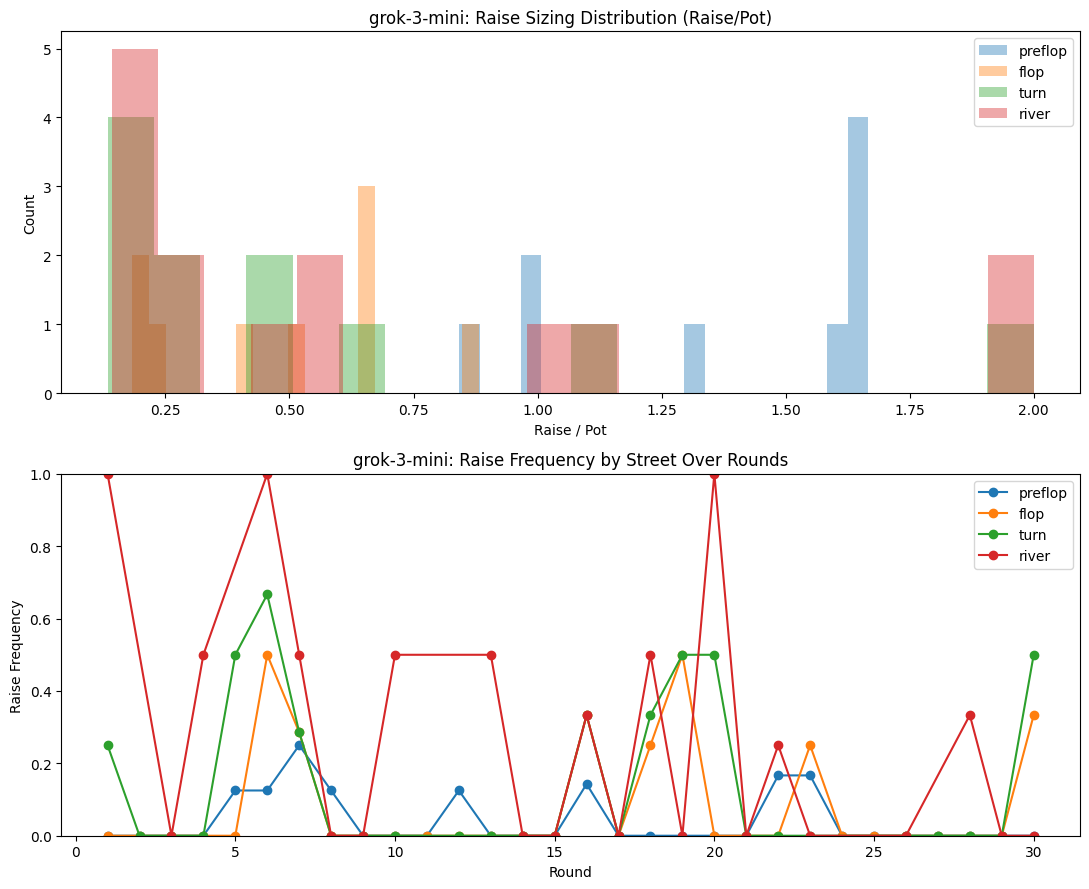


Saved one combined figure to: grok-3-mini_behavior_summary.pdf


In [6]:
import json
import math
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = "results.json"
TARGET = "Niko Grey"  # The raw/original name you want to analyze

player_to_llm = {
    "Emily Zhang": "deepseek-v3.2",
    "Robert Garcia": "qwen3-32b",
    "Jessica Liu": "gemini-2.5-flash-lite",
    "Alex Chen": "gpt-4.1-mini",
    "Sarah Johnson": "llama-4-maverick",
    "Niko Grey": "grok-3-mini",
    "Noah Kim": "loose passive bot",
    "Ava Park": "loose aggressive bot",
    "Noah Blake": "Maniac",
    "Lily Grant": "TightPassive",
    "Jade Park": "TightAggressive",
}

def safe_div(a, b):
    return a / b if b else 0.0

def display_name(raw_name: str) -> str:
    """Map a raw player/bot name to a human-readable model/style name."""
    if raw_name in player_to_llm:
        return player_to_llm[raw_name]
    return raw_name

def find_target_key(battles, target_name: str) -> str:
    """
    TARGET may be an old name (e.g., 'Ava Park') while JSON uses 'LAG Bot A'.
    Strategy:
      1) If TARGET is a key in players, use it directly
      2) Otherwise, use display_name(TARGET) and reverse-match a player key
         whose display_name(raw_key) equals it.
    """
    desired_display = display_name(target_name)

    for battle in battles:
        players = battle.get("players", {})
        if target_name in players:
            return target_name

        for raw in players.keys():
            if display_name(raw) == desired_display:
                return raw

    raise KeyError(f"Cannot find TARGET={target_name} (or mapped name={desired_display}) in players")

def extract_raise_amount(pack: dict) -> int | None:
    """
    In the new structure, action often lacks 'amount':
      action: {"action":"CALL"}  (no amount)
    Raise sizing may appear in reasoning text or opponent action strings:
      "RAISE to 15", "raise 150", etc.
    """
    # 1) action.amount (if present)
    act = pack.get("action") or {}
    if "amount" in act and act["amount"] is not None:
        try:
            return int(act["amount"])
        except:
            pass

    # 2) Parse from reasoning text
    reasoning = pack.get("reasoning", "") or ""
    m = re.search(r"RAISE\s*to\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"raise\s*(\d+)", reasoning, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    # 3) Parse from opponent_actions strings (same street)
    gs = pack.get("game_state") or {}
    opp = (gs.get("opponent_actions") or {})
    street = str(gs.get("street", "")).lower()
    acts = opp.get(street, []) if isinstance(opp, dict) else []
    for item in reversed(acts):
        s = str(item.get("action", ""))
        m2 = re.search(r"RAISE\s*to\s*(\d+)", s, flags=re.IGNORECASE)
        if m2:
            return int(m2.group(1))

    return None


# =========================
# Load results.json
# =========================
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

battles = data.get("battles", [])
if not battles:
    raise ValueError("No 'battles' found in results.json")

# Auto-locate the true player key in the new structure (e.g., 'LAG Bot A')
TARGET_KEY = find_target_key(battles, TARGET)
TARGET_NAME = display_name(TARGET_KEY)


# =========================
# (1) Battle-level summary
# =========================
battle_rows = []
for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue

    p = players[TARGET_KEY]
    hands_played = p.get("hands_played", 0)
    hands_folded = p.get("hands_folded", 0)
    hands_called = p.get("hands_called", 0)
    hands_raised = p.get("hands_raised", 0)

    abs_ = p.get("actions_by_street", {})
    pre = abs_.get("preflop", {})
    flo = abs_.get("flop", {})
    tur = abs_.get("turn", {})
    riv = abs_.get("river", {})

    battle_rows.append({
        "battle_id": b_id,
        "hands_played": hands_played,
        "fold_rate_%": p.get("fold_rate", safe_div(hands_folded, hands_played) * 100),
        "call_rate_%": p.get("call_rate", safe_div(hands_called, hands_played) * 100),
        "raise_rate_%": p.get("raise_rate", safe_div(hands_raised, hands_played) * 100),
        "aggression_factor": p.get("aggression_factor", None),
        "profit": p.get("total_profit_loss", None),

        "preflop_raise": pre.get("raise", None),
        "preflop_call": pre.get("call", None),
        "preflop_fold": pre.get("fold", None),

        "flop_raise": flo.get("raise", None),
        "flop_call": flo.get("call", None),
        "flop_fold": flo.get("fold", None),

        "turn_raise": tur.get("raise", None),
        "turn_call": tur.get("call", None),
        "turn_fold": tur.get("fold", None),

        "river_raise": riv.get("raise", None),
        "river_call": riv.get("call", None),
        "river_fold": riv.get("fold", None),
    })

df_battle = pd.DataFrame(battle_rows)


# =========================
# (2) Rebuild per-hand/per-street actions + raise sizing from reasoning_history
# =========================
action_rows = []
size_rows = []

for b_id, battle in enumerate(battles):
    players = battle.get("players", {})
    if TARGET_KEY not in players:
        continue
    p = players[TARGET_KEY]

    rh = p.get("reasoning_history", {})
    if not rh:
        continue

    for rnd_str, streets in rh.items():
        try:
            rnd = int(rnd_str)
        except:
            rnd = rnd_str

        for street, pack in (streets or {}).items():
            act_obj = pack.get("action") or {}
            act = act_obj.get("action", None)
            gs = pack.get("game_state") or {}

            pot = gs.get("pot_size", None)
            call_amt = gs.get("call_amount", None)
            min_raise = gs.get("min_raise", None)
            max_raise = gs.get("max_raise", None)
            hs = gs.get("env_hand_strength", gs.get("hand_strength", None))

            if act is None:
                continue

            # Amount fallback logic:
            # - CALL has no amount -> use call_amount
            # - FOLD -> 0
            # - RAISE -> parse from text / opponent actions if needed
            amt = act_obj.get("amount", None)
            if amt is None:
                if act == "CALL":
                    amt = 0 if (call_amt is None) else int(call_amt)
                elif act == "FOLD":
                    amt = 0
                elif act == "RAISE":
                    amt = extract_raise_amount(pack)

            action_rows.append({
                "battle_id": b_id,
                "round": rnd,
                "street": str(street).lower(),
                "action": act,
                "amount": amt,
                "pot_size": pot,
                "call_amount": call_amt,
                "min_raise": min_raise,
                "max_raise": max_raise,
                "hand_strength": hs
            })

            if act == "RAISE" and amt is not None and pot not in (None, 0):
                size_rows.append({
                    "battle_id": b_id,
                    "round": rnd,
                    "street": str(street).lower(),
                    "raise_amount": float(amt),
                    "pot_size": float(pot),
                    "raise_over_pot": float(amt) / float(pot),
                    "hand_strength": hs
                })

df_act = pd.DataFrame(action_rows)
df_size = pd.DataFrame(size_rows)

print("\n===== Street action counts =====")
if df_act.empty:
    print("No reasoning_history found.")
else:
    print(pd.crosstab(df_act["street"], df_act["action"]))

print("\n===== Raise sizing (raise/pot) summary =====")
if df_size.empty:
    print("No RAISE sizing data.")
else:
    print(df_size.groupby("street")["raise_over_pot"].describe())


# =========================
# (3) Behavioral metrics (VPIP/PFR/AF/big bet ratio)
# =========================
def compute_metrics(df_act, df_size):
    out = {}
    pre = df_act[df_act["street"].eq("preflop")].copy()

    # VPIP: put money voluntarily preflop (CALL/RAISE) with call_amount > 0
    pre_vpip = pre[(pre["action"].isin(["CALL", "RAISE"])) & (pre["call_amount"].fillna(0) > 0)]
    pre_pfr = pre[pre["action"].eq("RAISE")]

    out["hands_seen_preflop"] = len(pre)
    out["VPIP_%"] = safe_div(len(pre_vpip), len(pre)) * 100 if len(pre) else 0
    out["PFR_%"] = safe_div(len(pre_pfr), len(pre)) * 100 if len(pre) else 0

    for st in ["flop", "turn", "river"]:
        st_df = df_act[df_act["street"].eq(st)]
        r = (st_df["action"] == "RAISE").sum()
        c = (st_df["action"] == "CALL").sum()
        out[f"{st}_agg_factor"] = safe_div(r, c) if (r or c) else np.nan

    if not df_size.empty:
        out["big_bet_ratio_%(>=0.75pot)"] = (df_size["raise_over_pot"] >= 0.75).mean() * 100
        out["median_raise_over_pot"] = df_size["raise_over_pot"].median()
    else:
        out["big_bet_ratio_%(>=0.75pot)"] = np.nan
        out["median_raise_over_pot"] = np.nan

    return out

if not df_act.empty:
    metrics = compute_metrics(df_act, df_size)
    print(f"\n===== {TARGET_NAME} metrics (behavioral) =====")
    for k, v in metrics.items():
        ok = isinstance(v, (int, float)) and not (isinstance(v, float) and math.isnan(v))
        print(f"{k}: {v:.3f}" if ok else f"{k}: {v}")


# =========================
# (4) Output ONE image (single PNG)
#     - Top: raise sizing distribution (if available)
#     - Bottom: raise frequency by street over rounds (if available)
# =========================
OUT_PNG = f"{TARGET_NAME}_behavior_summary.pdf"

plots_available = []
has_size_plot = (not df_size.empty)
has_freq_plot = (not df_act.empty)

if not has_size_plot and not has_freq_plot:
    print("\nNo data to plot (both df_size and df_act are empty).")
else:
    nrows = int(has_size_plot) + int(has_freq_plot)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(11, 4.5 * nrows))
    if nrows == 1:
        axes = [axes]

    ax_i = 0

    # (A) Raise sizing histogram overlays by street
    if has_size_plot:
        ax = axes[ax_i]
        for st in ["preflop", "flop", "turn", "river"]:
            s = df_size[df_size["street"].eq(st)]["raise_over_pot"].dropna()
            if len(s) == 0:
                continue
            ax.hist(s, bins=20, alpha=0.4, label=st)
        ax.set_xlabel("Raise / Pot")
        ax.set_ylabel("Count")
        ax.set_title(f"{TARGET_NAME}: Raise Sizing Distribution (Raise/Pot)")
        ax.legend()
        ax_i += 1

    # (B) Raise frequency line by street over rounds
    if has_freq_plot:
        ax = axes[ax_i]
        tmp = df_act.copy()
        tmp["is_raise"] = (tmp["action"] == "RAISE").astype(int)
        g = tmp.groupby(["street", "round"])["is_raise"].mean().reset_index()

        for st in ["preflop", "flop", "turn", "river"]:
            sub = g[g["street"] == st]
            if sub.empty:
                continue
            ax.plot(sub["round"], sub["is_raise"], marker="o", label=st)

        ax.set_ylim(0, 1)
        ax.set_xlabel("Round")
        ax.set_ylabel("Raise Frequency")
        ax.set_title(f"{TARGET_NAME}: Raise Frequency by Street Over Rounds")
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"\nSaved one combined figure to: {OUT_PNG}")